In [155]:
# from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

image_cv2 = cv2.imread("/Users/ghoziwaridi/KULIAH/1. Kuliah/Komputer Vision/Project/data/raw/Training/notumor/Tr-no_15.jpg")
image_cv2 = cv2.cvtColor(image_cv2, cv2.COLOR_BGR2GRAY)
print(image_cv2.shape)

image_cv2


window_image = image_cv2[0:3, 0:3] # 
window_image # Mengambil pixel 1-3


(450, 600)


array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]], dtype=uint8)

In [ ]:
window_image = np.array(image_cv2[222:225, 297:300]) ## Mengubah ke dalam bentuk numpy array kapasitas nilai lebih besar dan mudah melakukan operasi
window_image

array([[92, 65, 72],
       [94, 69, 76],
       [91, 65, 70]], dtype=uint8)

## Kernel

In [ ]:
kernel = np.array([
   [ 0, -1,  0],
   [-1,  5, -1],
   [ 0, -1,  0]
])



## Operais manual dari konvolusi (operasi ini menggunakan perhitungan linear)

In [159]:
new_pixel1 = (window_image[0][0] * kernel[0][0]) + (window_image[0][1] * kernel[0][1]) + (window_image[0][2] * kernel[0][2]) + (window_image[1][0] * kernel[1][0]) + (window_image[1][1] * kernel[1][1]) + (window_image[1][2] * kernel[1][2]) + (window_image[2][0] * kernel[2][0]) + (window_image[2][1] * kernel[2][1]) + (window_image[2][2] * kernel[2][2])
new_pixel1

np.int64(45)

### Operasi otomatis dengan penggunaan for dengan code yang lebih ringkas

In [160]:
new_pixel = 0
hasil = []
for i in range(3):
   for j in range(3):
      new_pixel += int(window_image[i][j]) * kernel[i][j]
      hasil.append(new_pixel)

In [161]:
new_pixel

np.int64(45)

In [162]:
#        [92, 65, 72],
#        [94, 69, 76],
#        [91, 65, 70]


   # [-1, -1, -1],
   # [-1, 9, -1],
   # [-1, -1, -1]
   

hasil

[np.int64(0),
 np.int64(-65),
 np.int64(-65),
 np.int64(-159),
 np.int64(186),
 np.int64(110),
 np.int64(110),
 np.int64(45),
 np.int64(45)]

### Proses perhitungan convolusi menggunakan library dari OpenCV

In [163]:
hasil_conv = cv2.filter2D(image_cv2, -1, kernel)

### Menampilkan gambar yang telah melewati proses konvolusi dengan menggunakan matplotlib

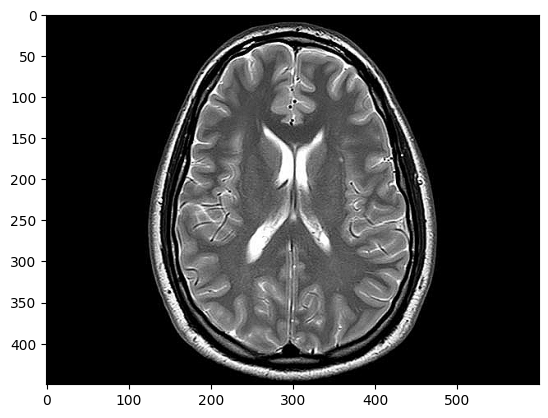

In [164]:
plt.imshow(hasil_conv, cmap='gray')
plt.show()

### Melakukan convolusi ke 2 sekaligus melihat hasil histogram penyebaran data

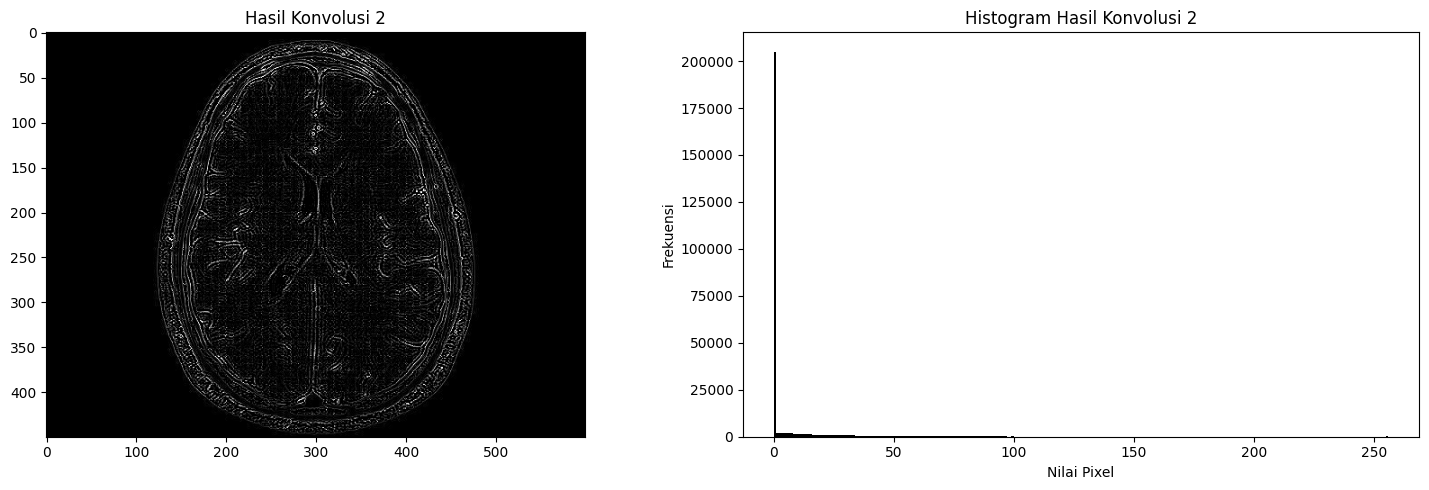

In [ ]:
kernel_2 = np.array([
   [ 0,  1,  0],
   [ 1, -4,  1],
   [ 0,  1,  0]
])
hasil_conv_2 = cv2.filter2D(hasil_conv, -1, kernel_2)

plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
plt.imshow(hasil_conv_2, cmap='gray')
plt.title('Hasil Konvolusi 2')


plt.subplot(1, 2, 2)
plt.hist(hasil_conv_2.ravel(), bins=256, range=(0, 256), color='black')
plt.title('Histogram Hasil Konvolusi 2')
plt.xlabel('Nilai Pixel')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frekuensi')

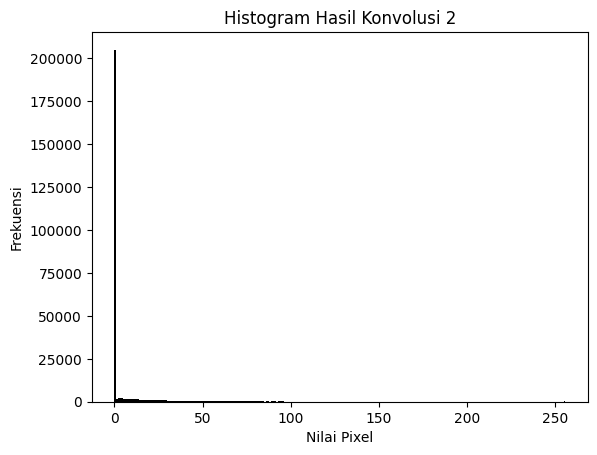

In [169]:
plt.hist(hasil_conv_2.ravel(), bins=256, range=(0, 256), color='black')
plt.title('Histogram Hasil Konvolusi 2')
plt.xlabel('Nilai Pixel')
plt.ylabel('Frekuensi')

Nilai minimum: 0
Nilai maksimum: 255


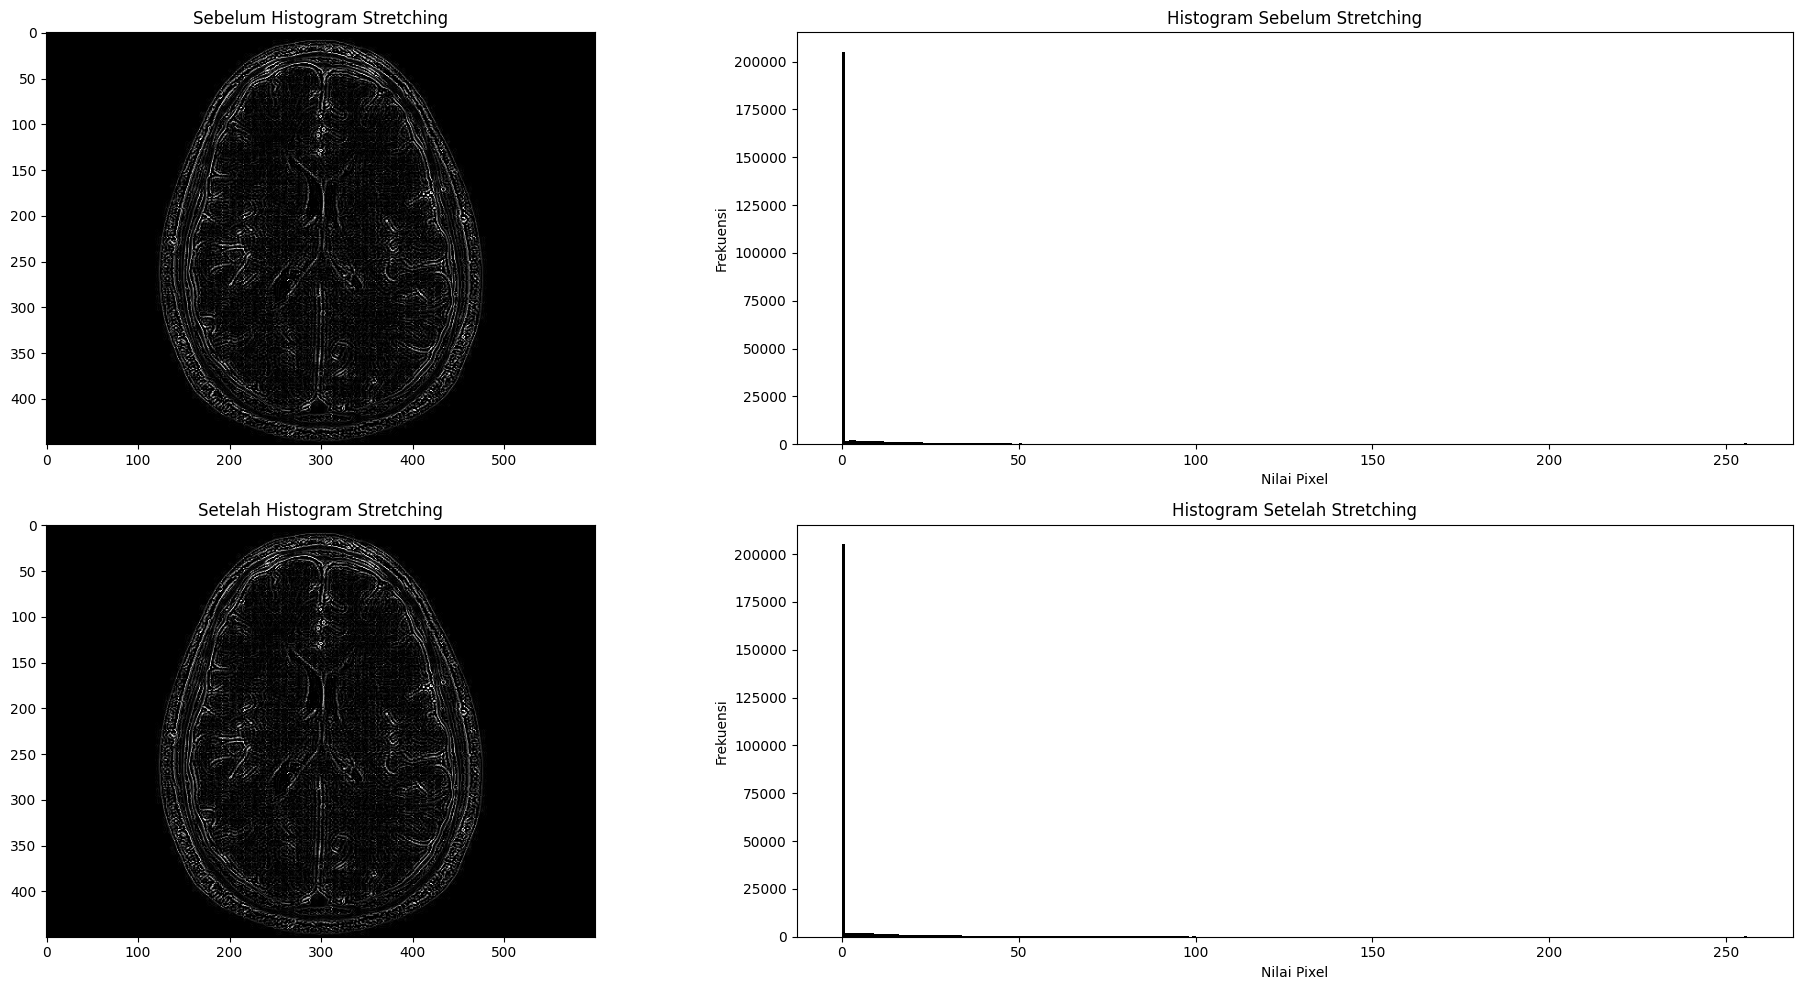

In [171]:
# Histogram Stretching
min_val = hasil_conv_2.min()
max_val = hasil_conv_2.max()

print(f"Nilai minimum: {min_val}")
print(f"Nilai maksimum: {max_val}")

# Rumus: stretched = ((pixel - min) / (max - min)) * 255
hasil_stretched = ((hasil_conv_2 - min_val) / (max_val - min_val) * 255).astype(np.uint8)

# Tampilkan perbandingan
plt.figure(figsize=(20, 10))

# Gambar sebelum stretching
plt.subplot(2, 2, 1)
plt.imshow(hasil_conv_2, cmap='gray')
plt.title('Sebelum Histogram Stretching')

# Histogram sebelum stretching
plt.subplot(2, 2, 2)
plt.hist(hasil_conv_2.ravel(), bins=256, range=(0, 256), color='black')
plt.title('Histogram Sebelum Stretching')
plt.xlabel('Nilai Pixel')
plt.ylabel('Frekuensi')

# Gambar setelah stretching
plt.subplot(2, 2, 3)
plt.imshow(hasil_stretched, cmap='gray')
plt.title('Setelah Histogram Stretching')

# Histogram setelah stretching
plt.subplot(2, 2, 4)
plt.hist(hasil_stretched.ravel(), bins=256, range=(0, 256), color='black')
plt.title('Histogram Setelah Stretching')
plt.xlabel('Nilai Pixel')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

### Menampilakan semua gambar hasil dari konvolusi

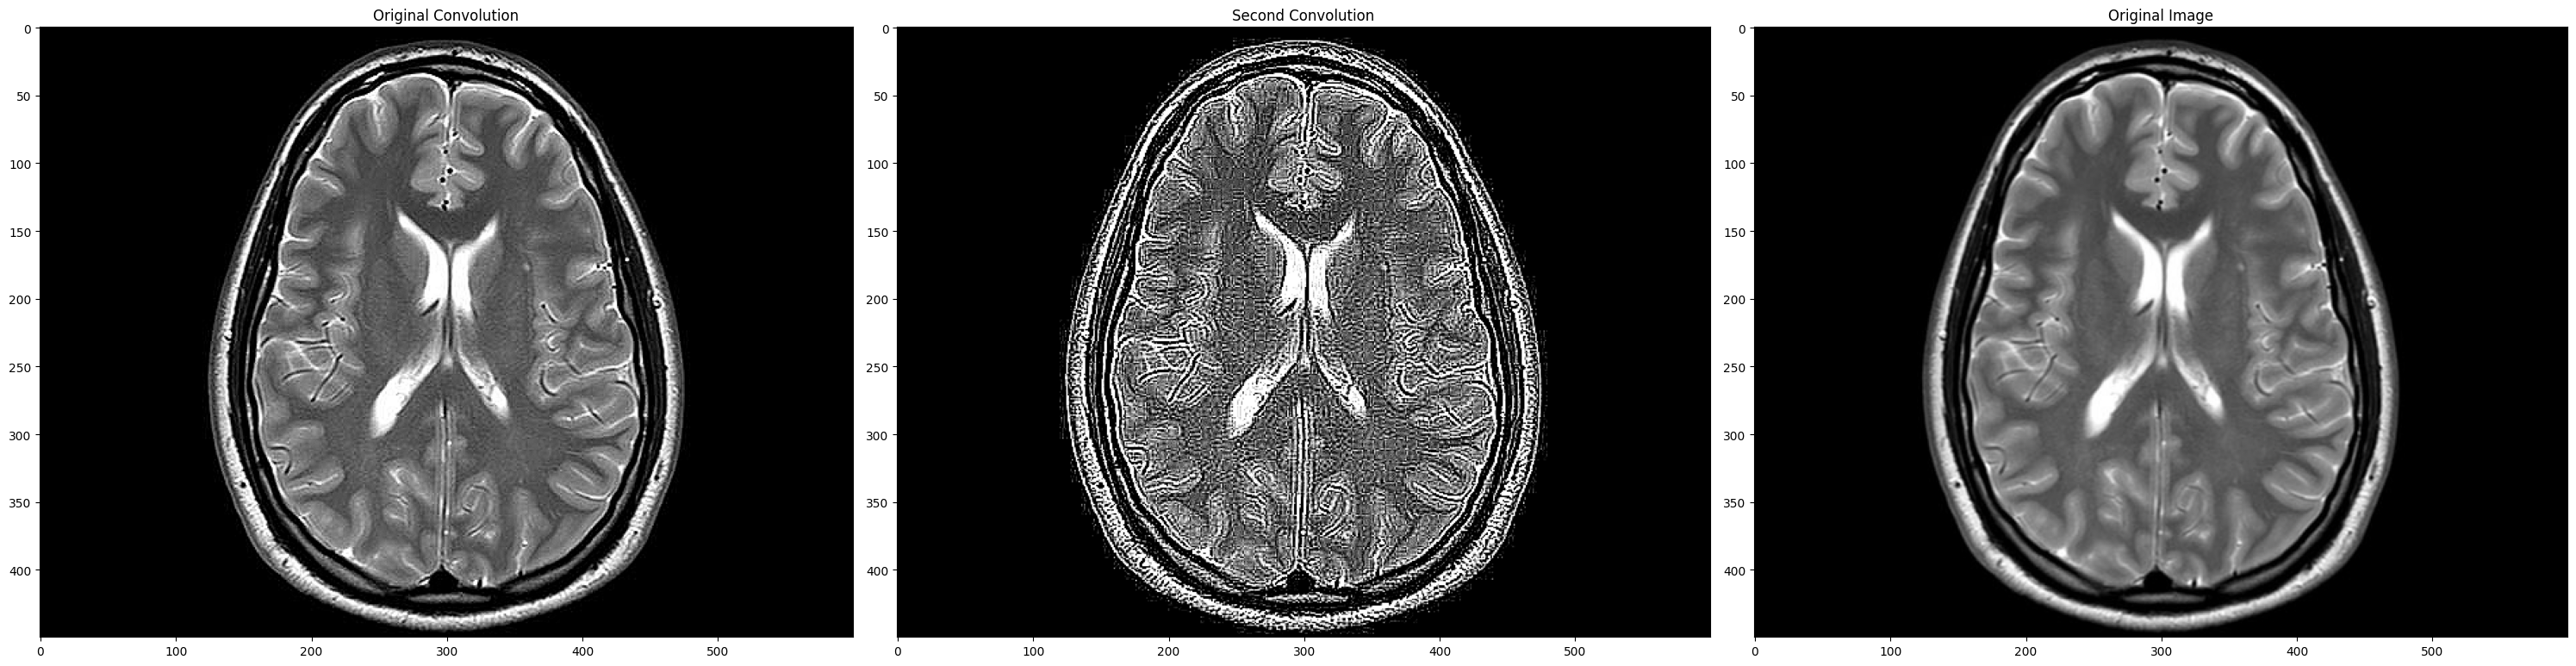

In [ ]:
plt.figure(figsize=(30, 15))

plt.subplot(1, 3, 1)
plt.imshow(hasil_conv, cmap='gray')
plt.title('Original Convolution')

plt.subplot(1, 3, 2)
plt.imshow(hasil_conv_2, cmap='gray')
plt.title('Second Convolution')

plt.subplot(1, 3, 3)
plt.imshow(image_cv2, cmap='gray')
plt.title('Original Image')

plt.tight_layout()
plt.show()